# Channel-pair sampling

Completed 48-record panel · $T=1000$ · p90 (289 SPIs) · 128 draws per instance.

Sample $b$ channel dyads uniformly without replacement, retaining both directions and using the same pairs across SPIs. Compare sampled $\hat{\mathbf z}$ with each recording’s exact all-pair Pearson SPI–SPI vector $\mathbf z$. This tests numerical approximation, not extraction speedup.

In [1]:
from pathlib import Path
from IPython.display import Image, display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'results/large_m_pair_baselines_260917/sampling-available/report.json').is_file())
RESULTS = ROOT / 'results/large_m_pair_baselines_260917/sampling-available'

def show_figure(relative_path):
    display(Image(filename=str(RESULTS / relative_path), width=1100))

## Whole-vector \( z \) recovery w/ MEG

Four instances at each $M=64,100,243$. Left: RMSE across evaluable features. Middle: 95th-percentile absolute error **across features within a draw**. Right: fraction of reference-valid features still defined. Lines are medians; bands are 10–90% instance/draw spread, not confidence intervals.

Error is conditional on retained features; reference-valid masks differ between recordings. Median 100% coverage does not mean every draw retains every feature. The RMSE $0.05$ line is illustrative.

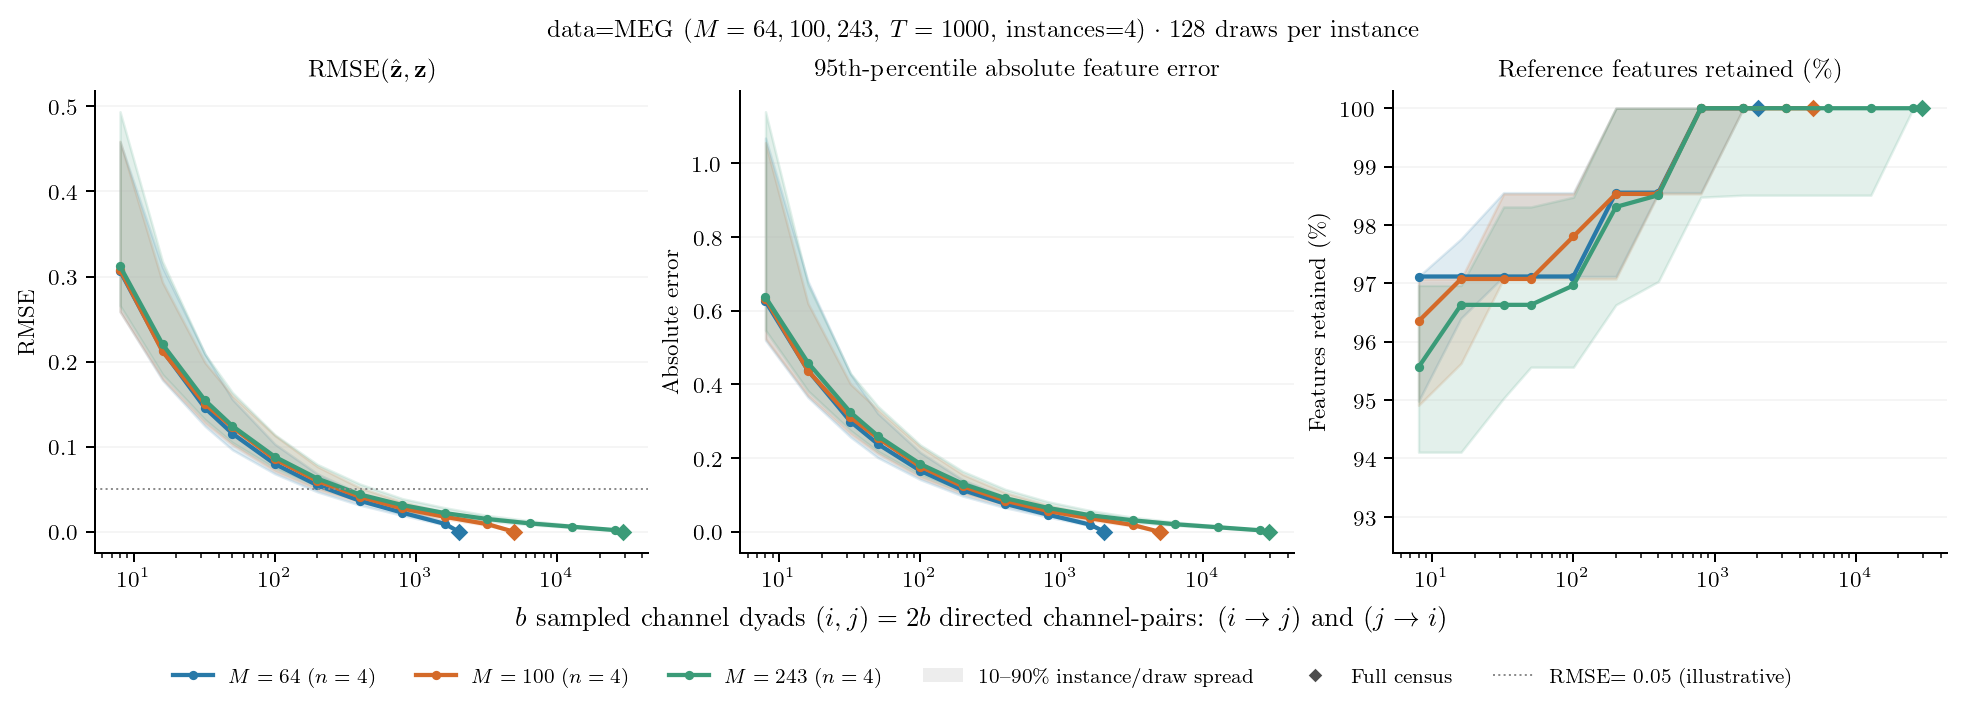

In [2]:
show_figure('meg-full-vector-convergence.png')

## Individual SPI–SPI features

Twelve selected coordinates for the same MEG instance at each channel count. Dashed lines: exact values; coloured lines: sampling medians; bands: 2.5–97.5% of draws; faint paths: all 128 nested draws ($\alpha=0.05$). Vertical scales differ. Pearson here is covariance on variance-one input channels.

### $M=64$

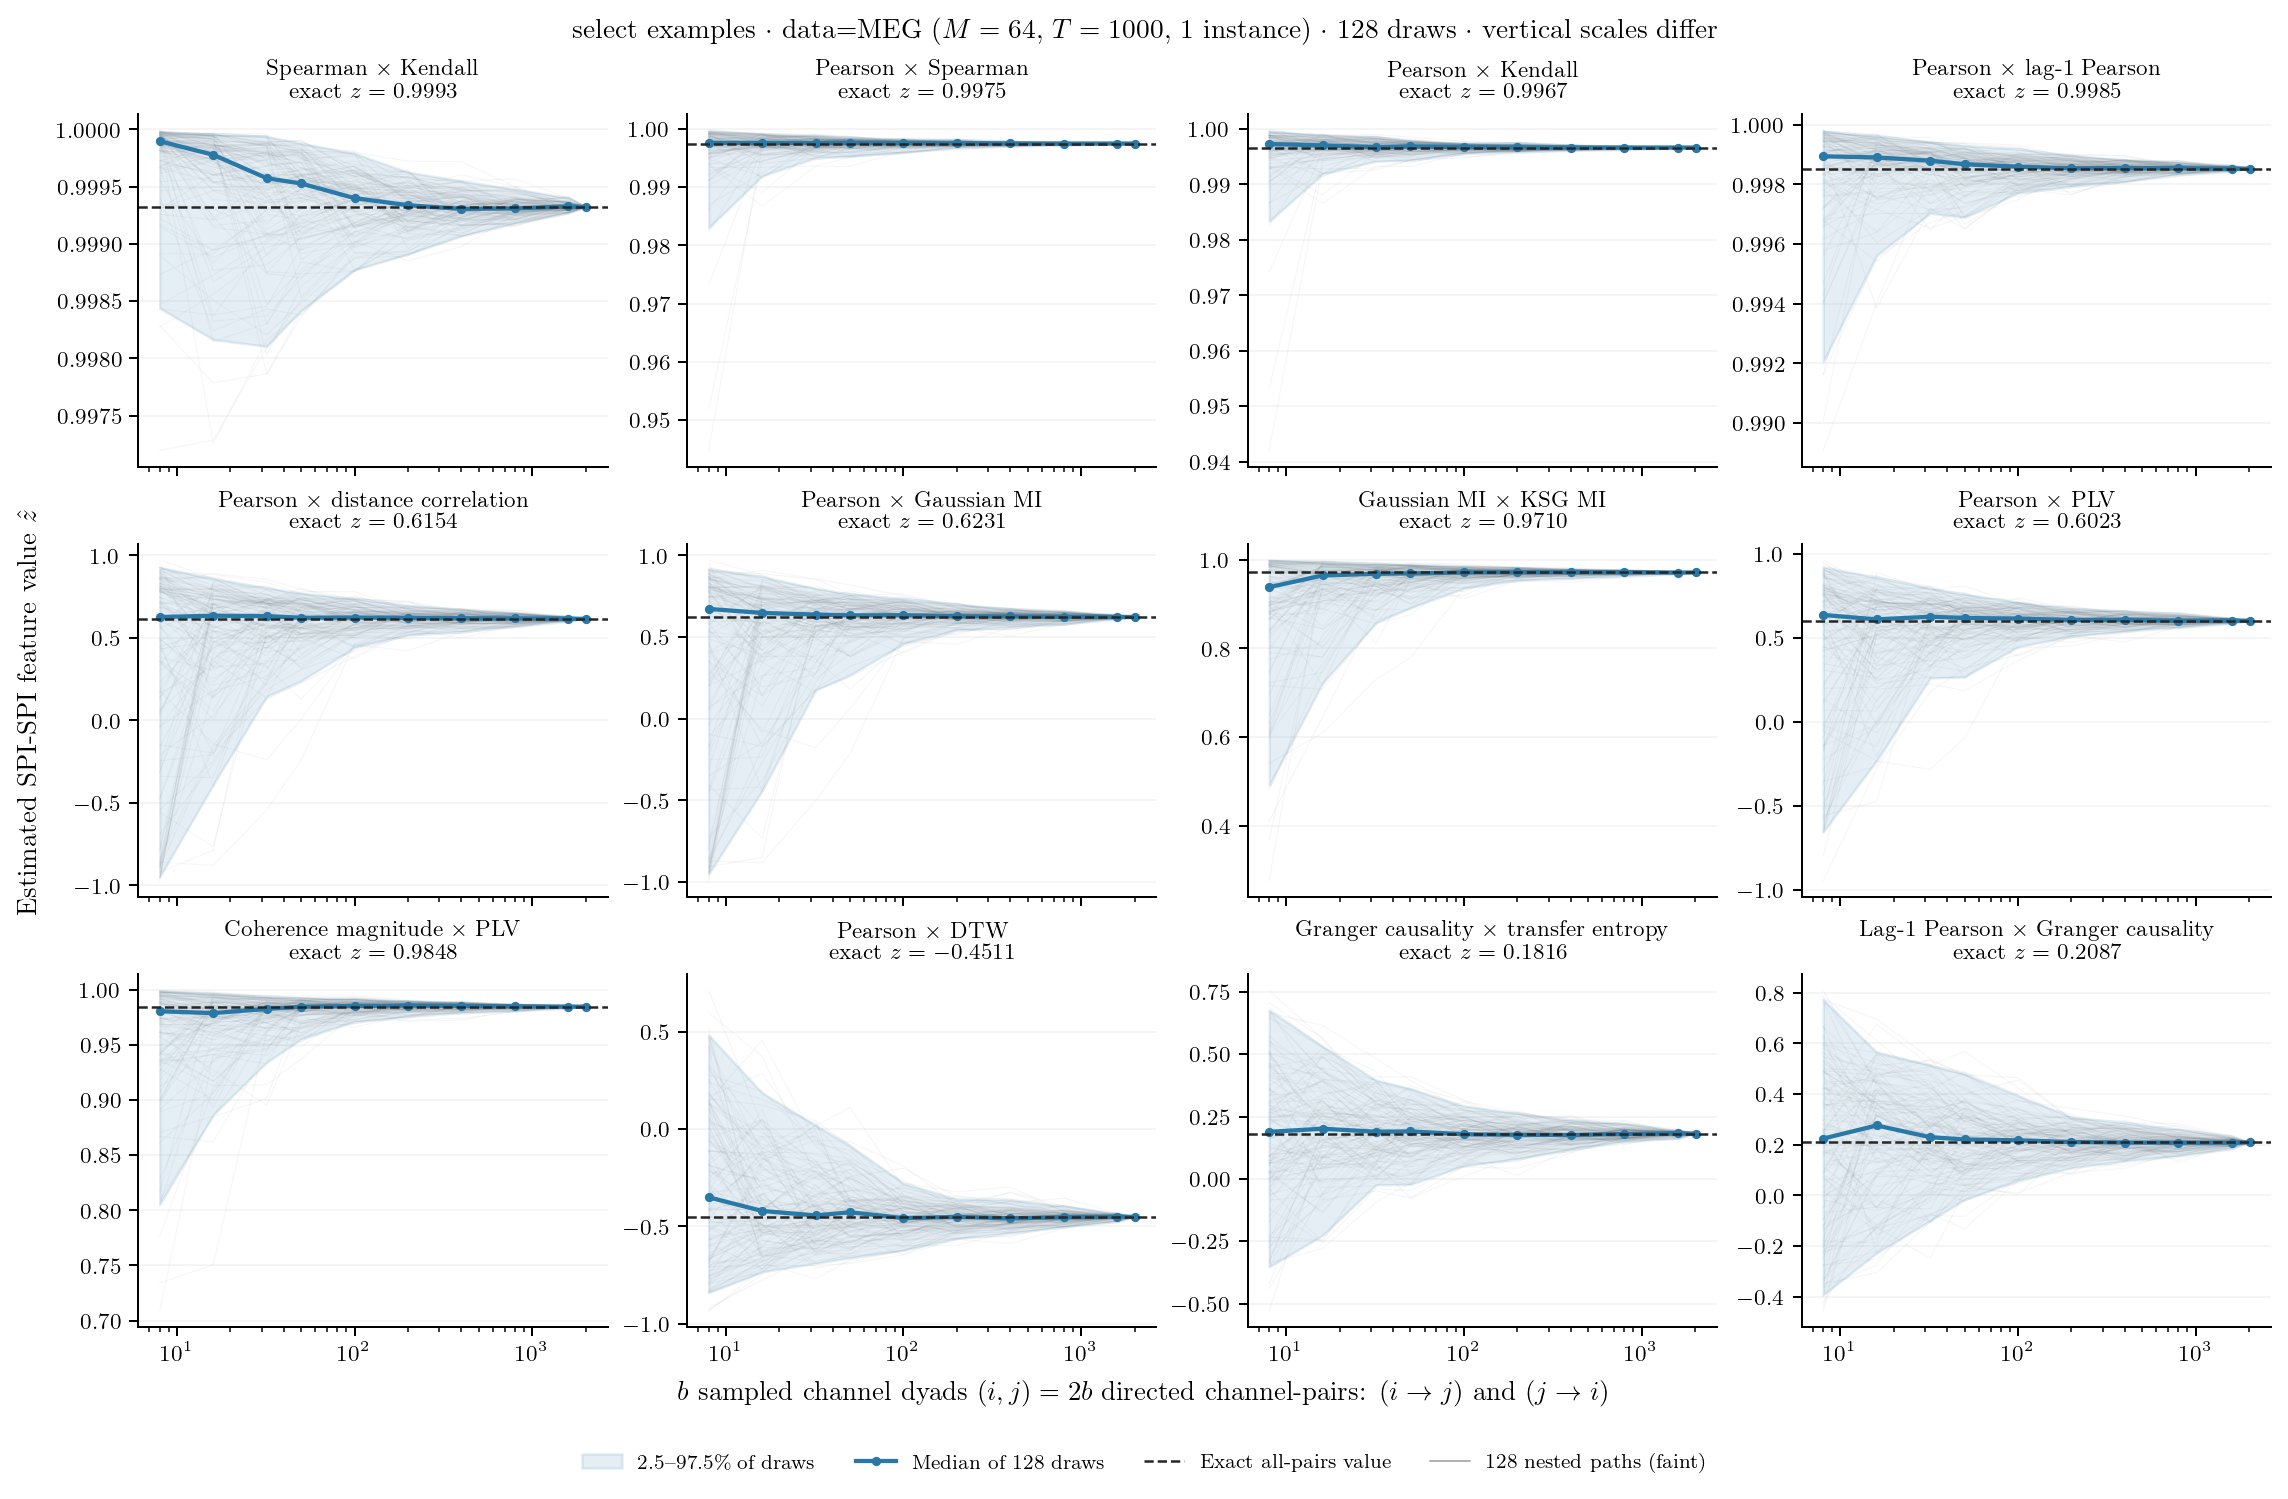

In [3]:
show_figure('coordinate-gallery/coordinate-gallery-M64.png')

### $M=100$

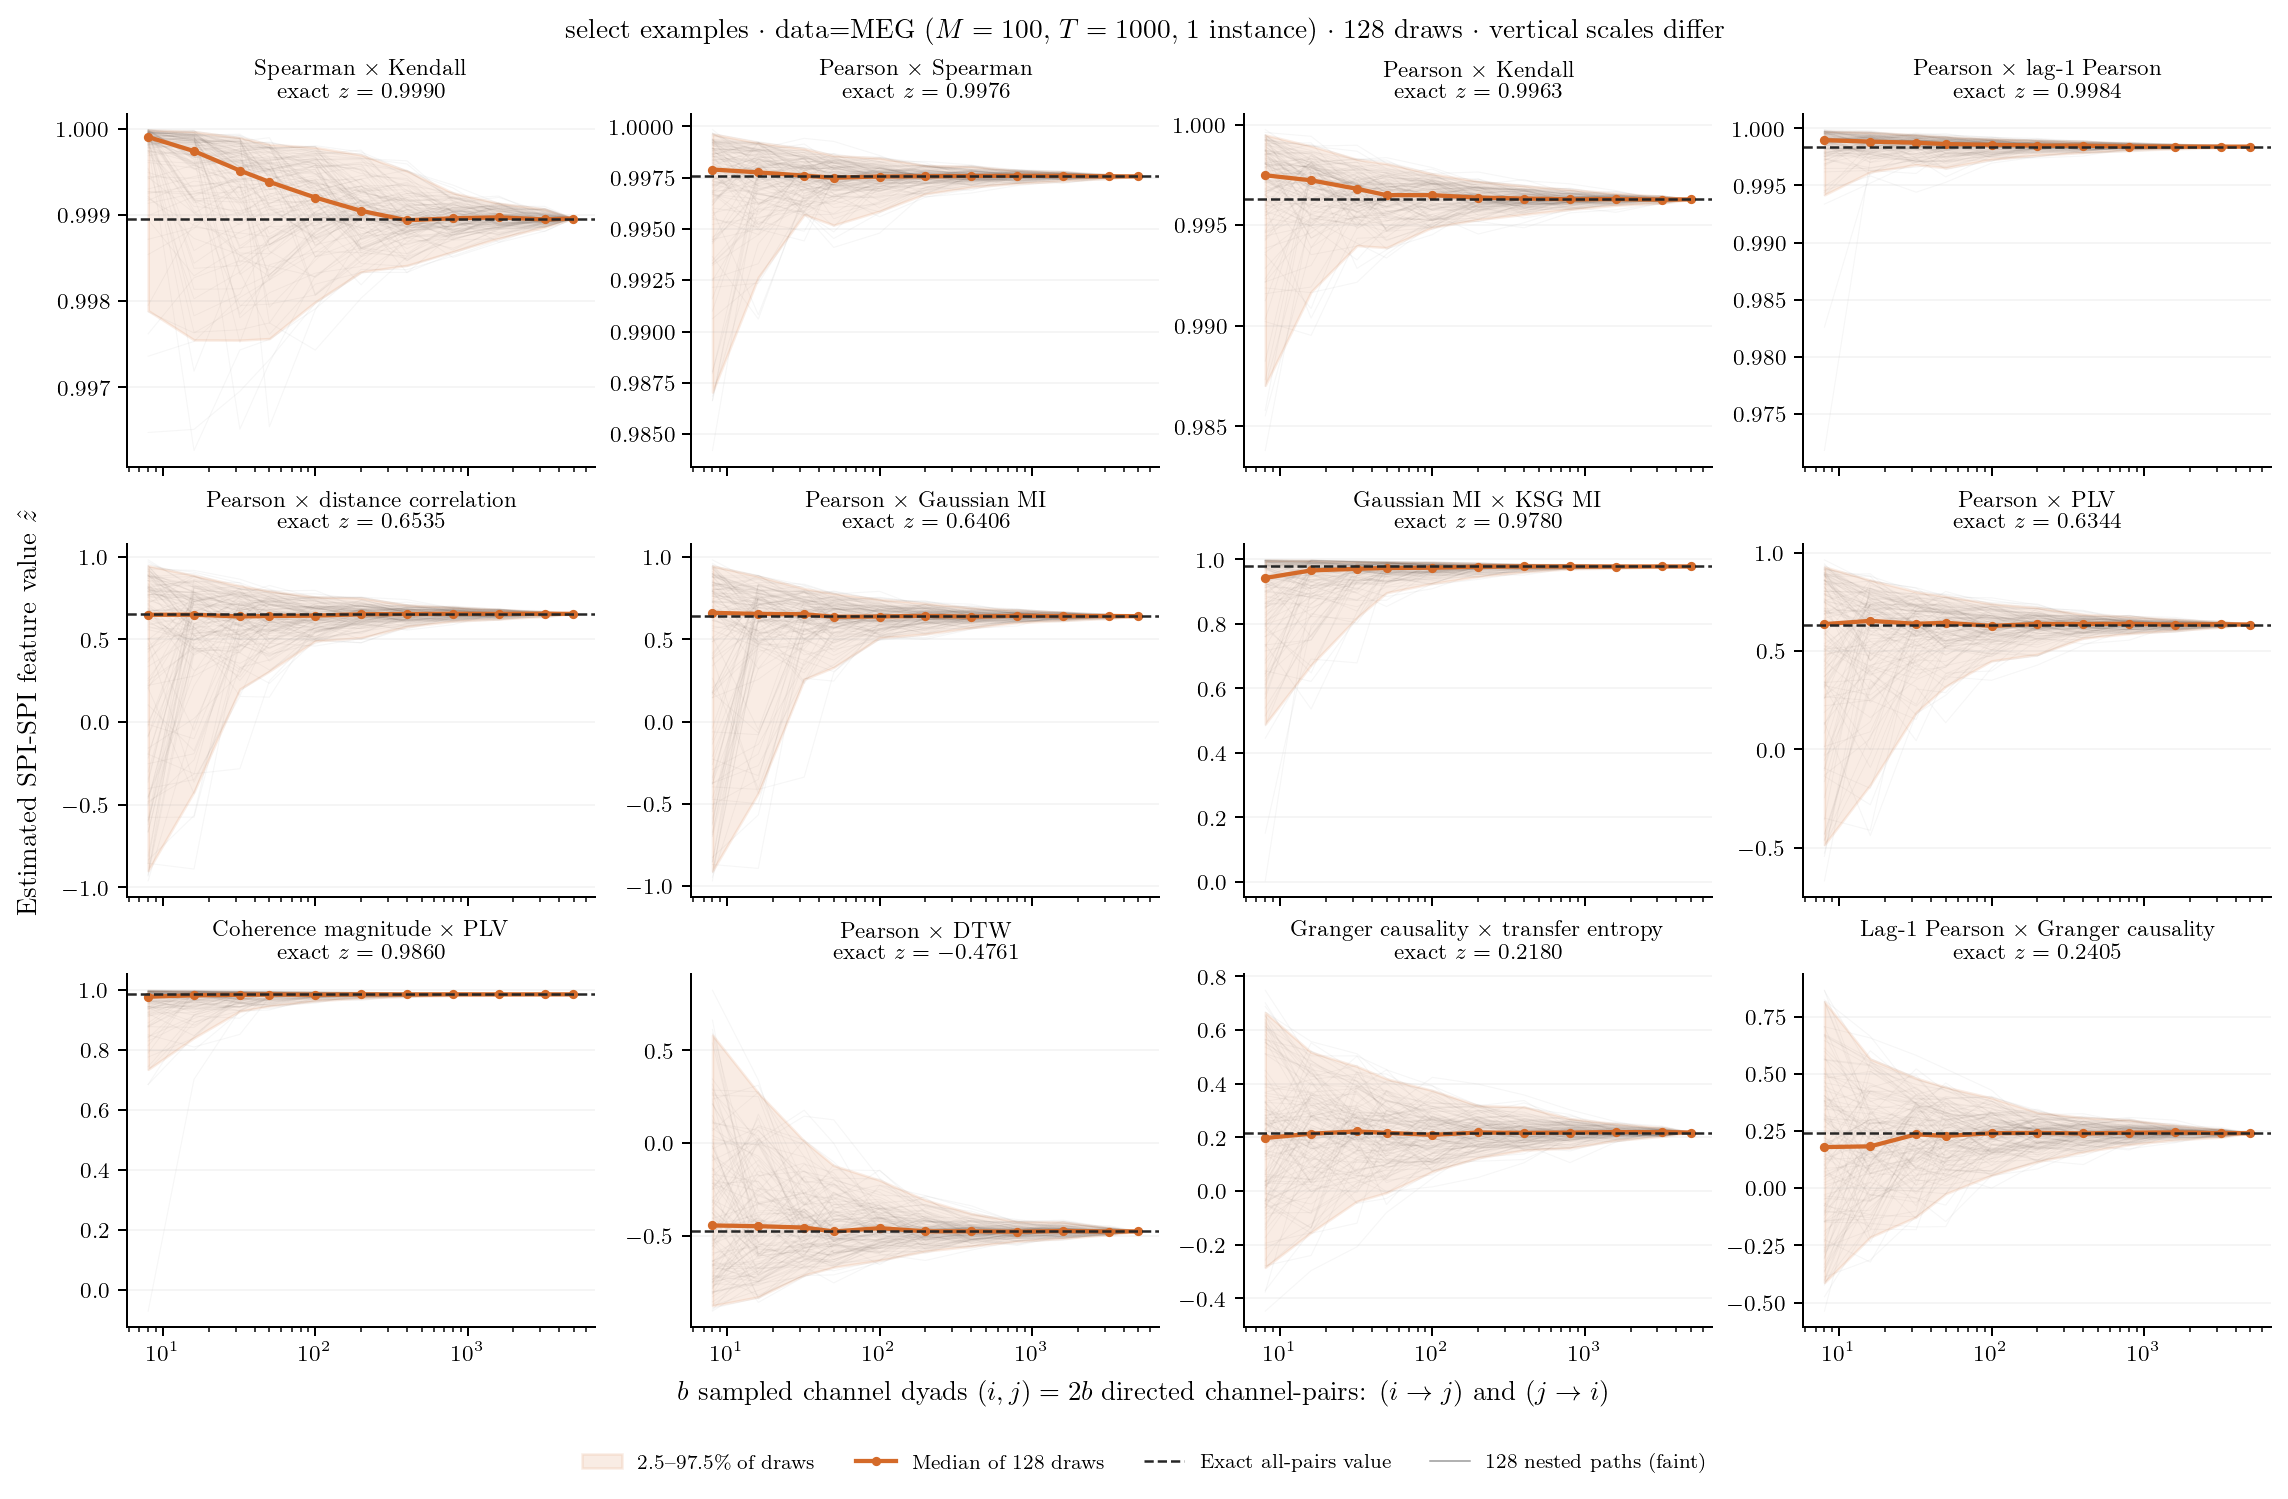

In [4]:
show_figure('coordinate-gallery/coordinate-gallery-M100.png')

### $M=243$

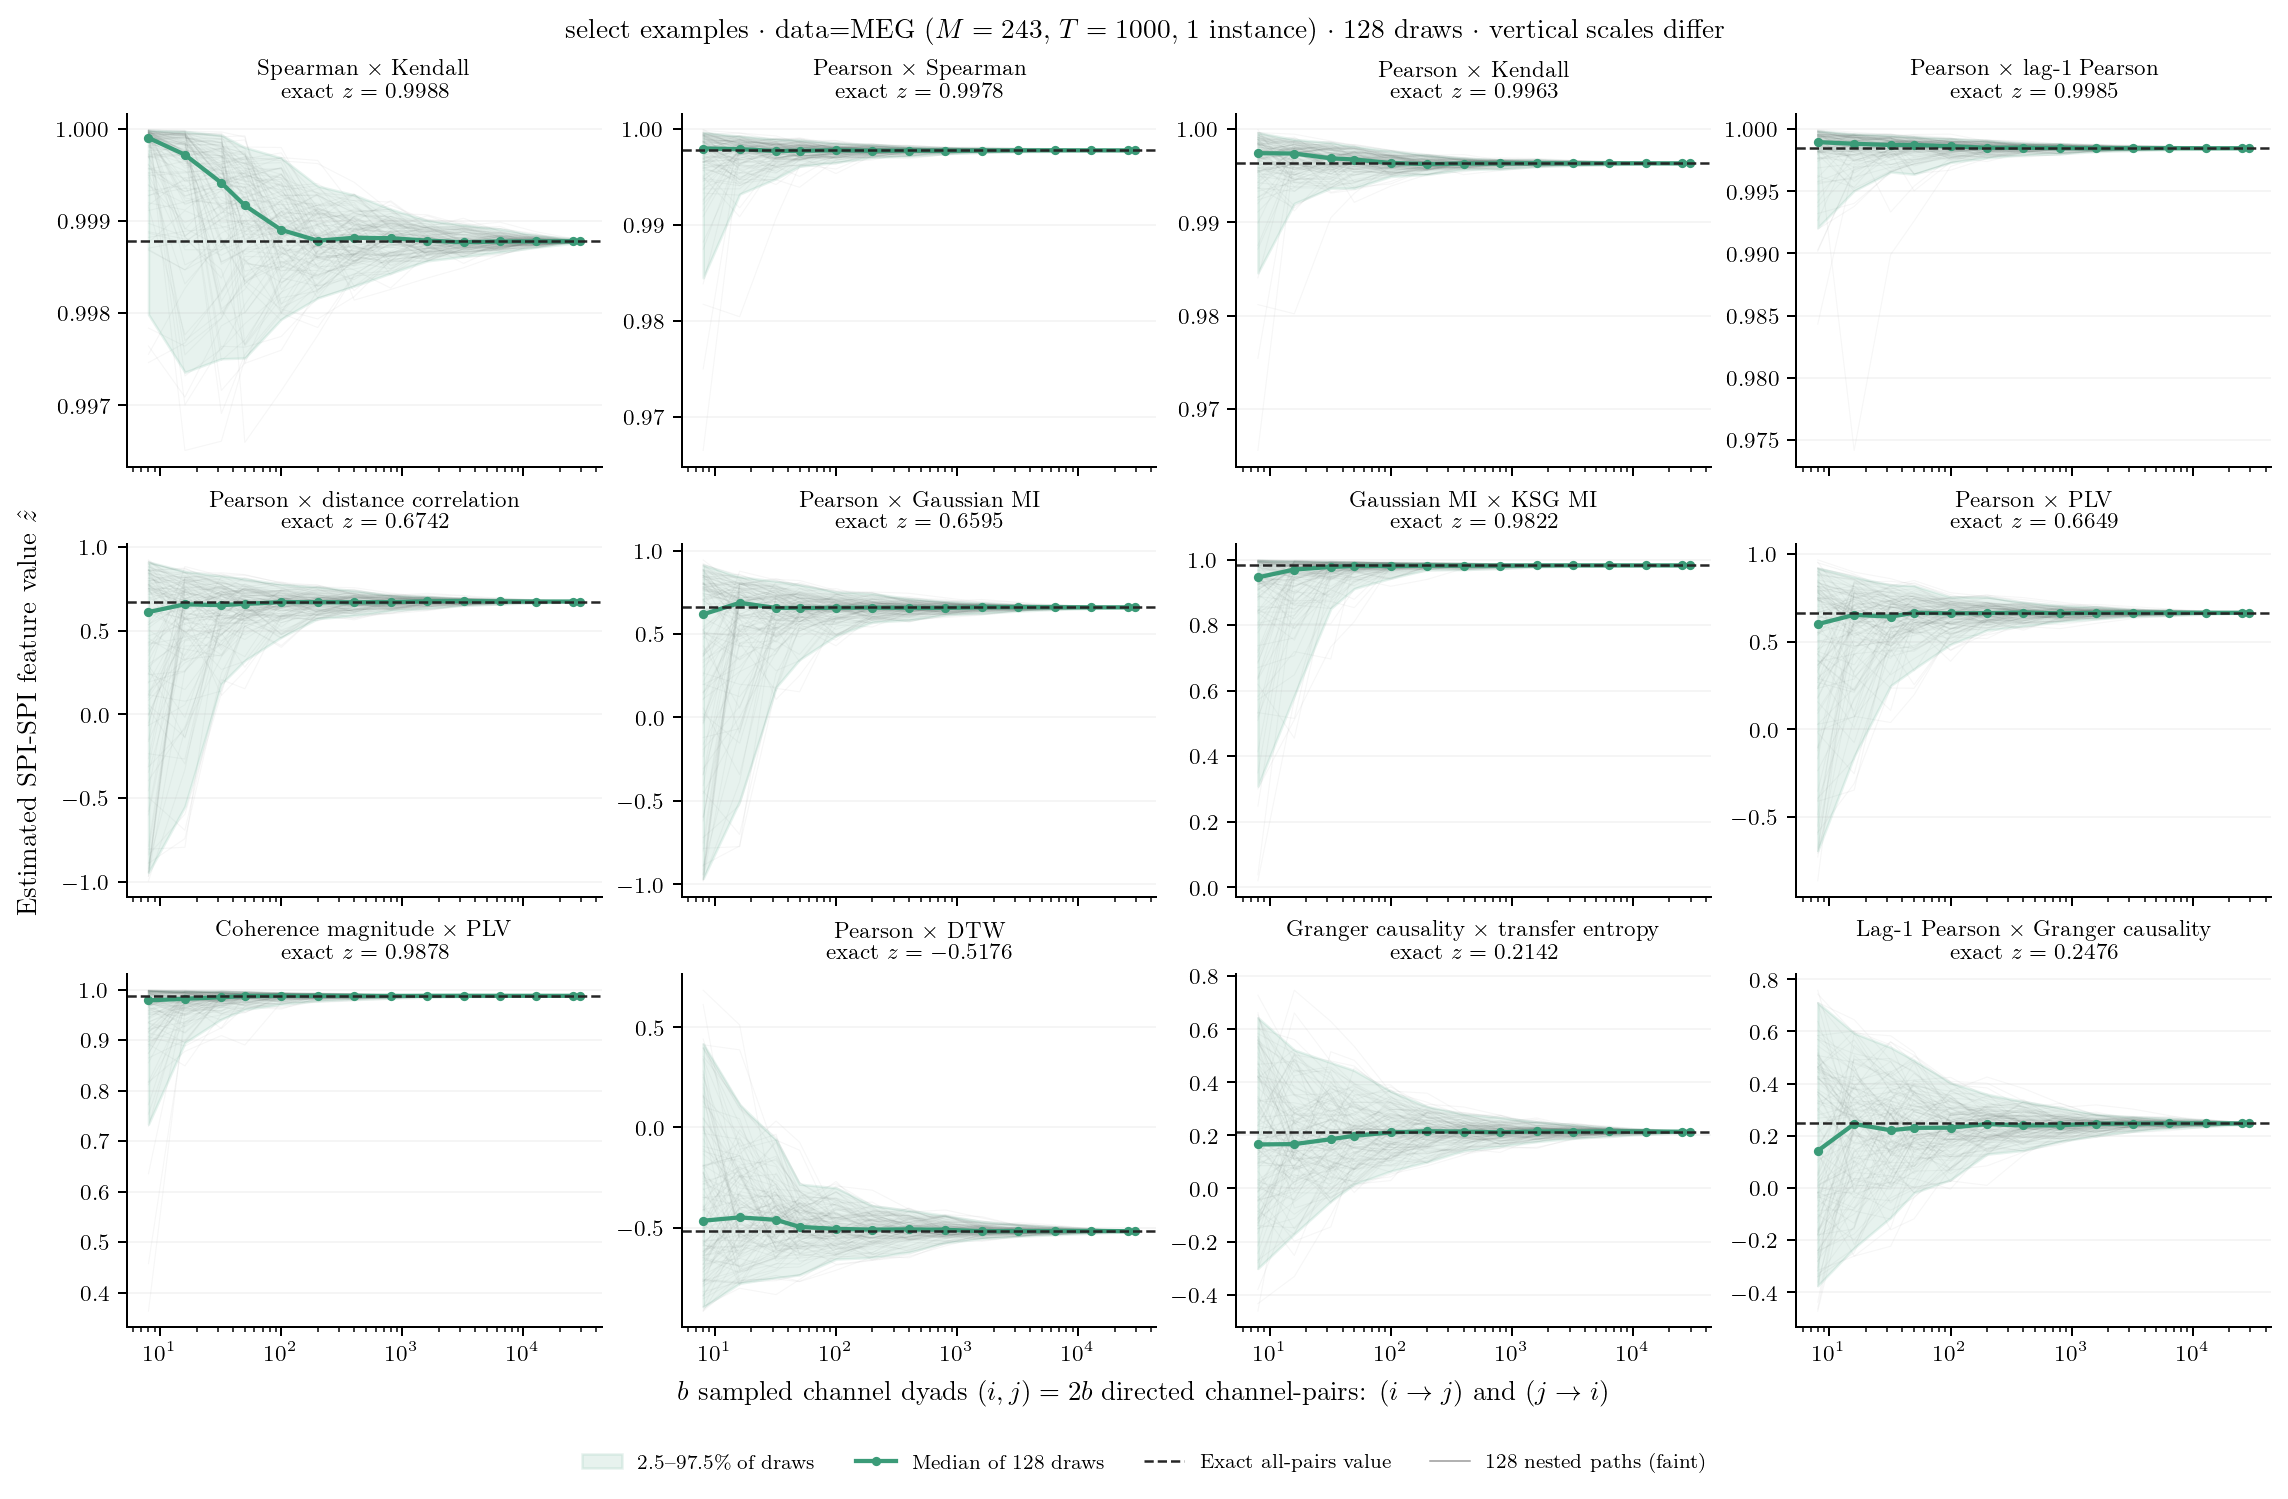

In [5]:
show_figure('coordinate-gallery/coordinate-gallery-M243.png')

## Supporting comparison: CML and VAR

Same three metrics and sampling scheme across all 48 records. Counts are shown per size; these are descriptive examples, not a universal sampling-budget estimate. CML observes subsets of a larger lattice; VAR uses $M=N$.

One MEG $M=243$ instance has two band-maximum SPIs constant except at one directed entry: missing that dyad makes 533 reference-valid features undefined. This explains a persistent coverage tail; it does not establish rare physical coupling.

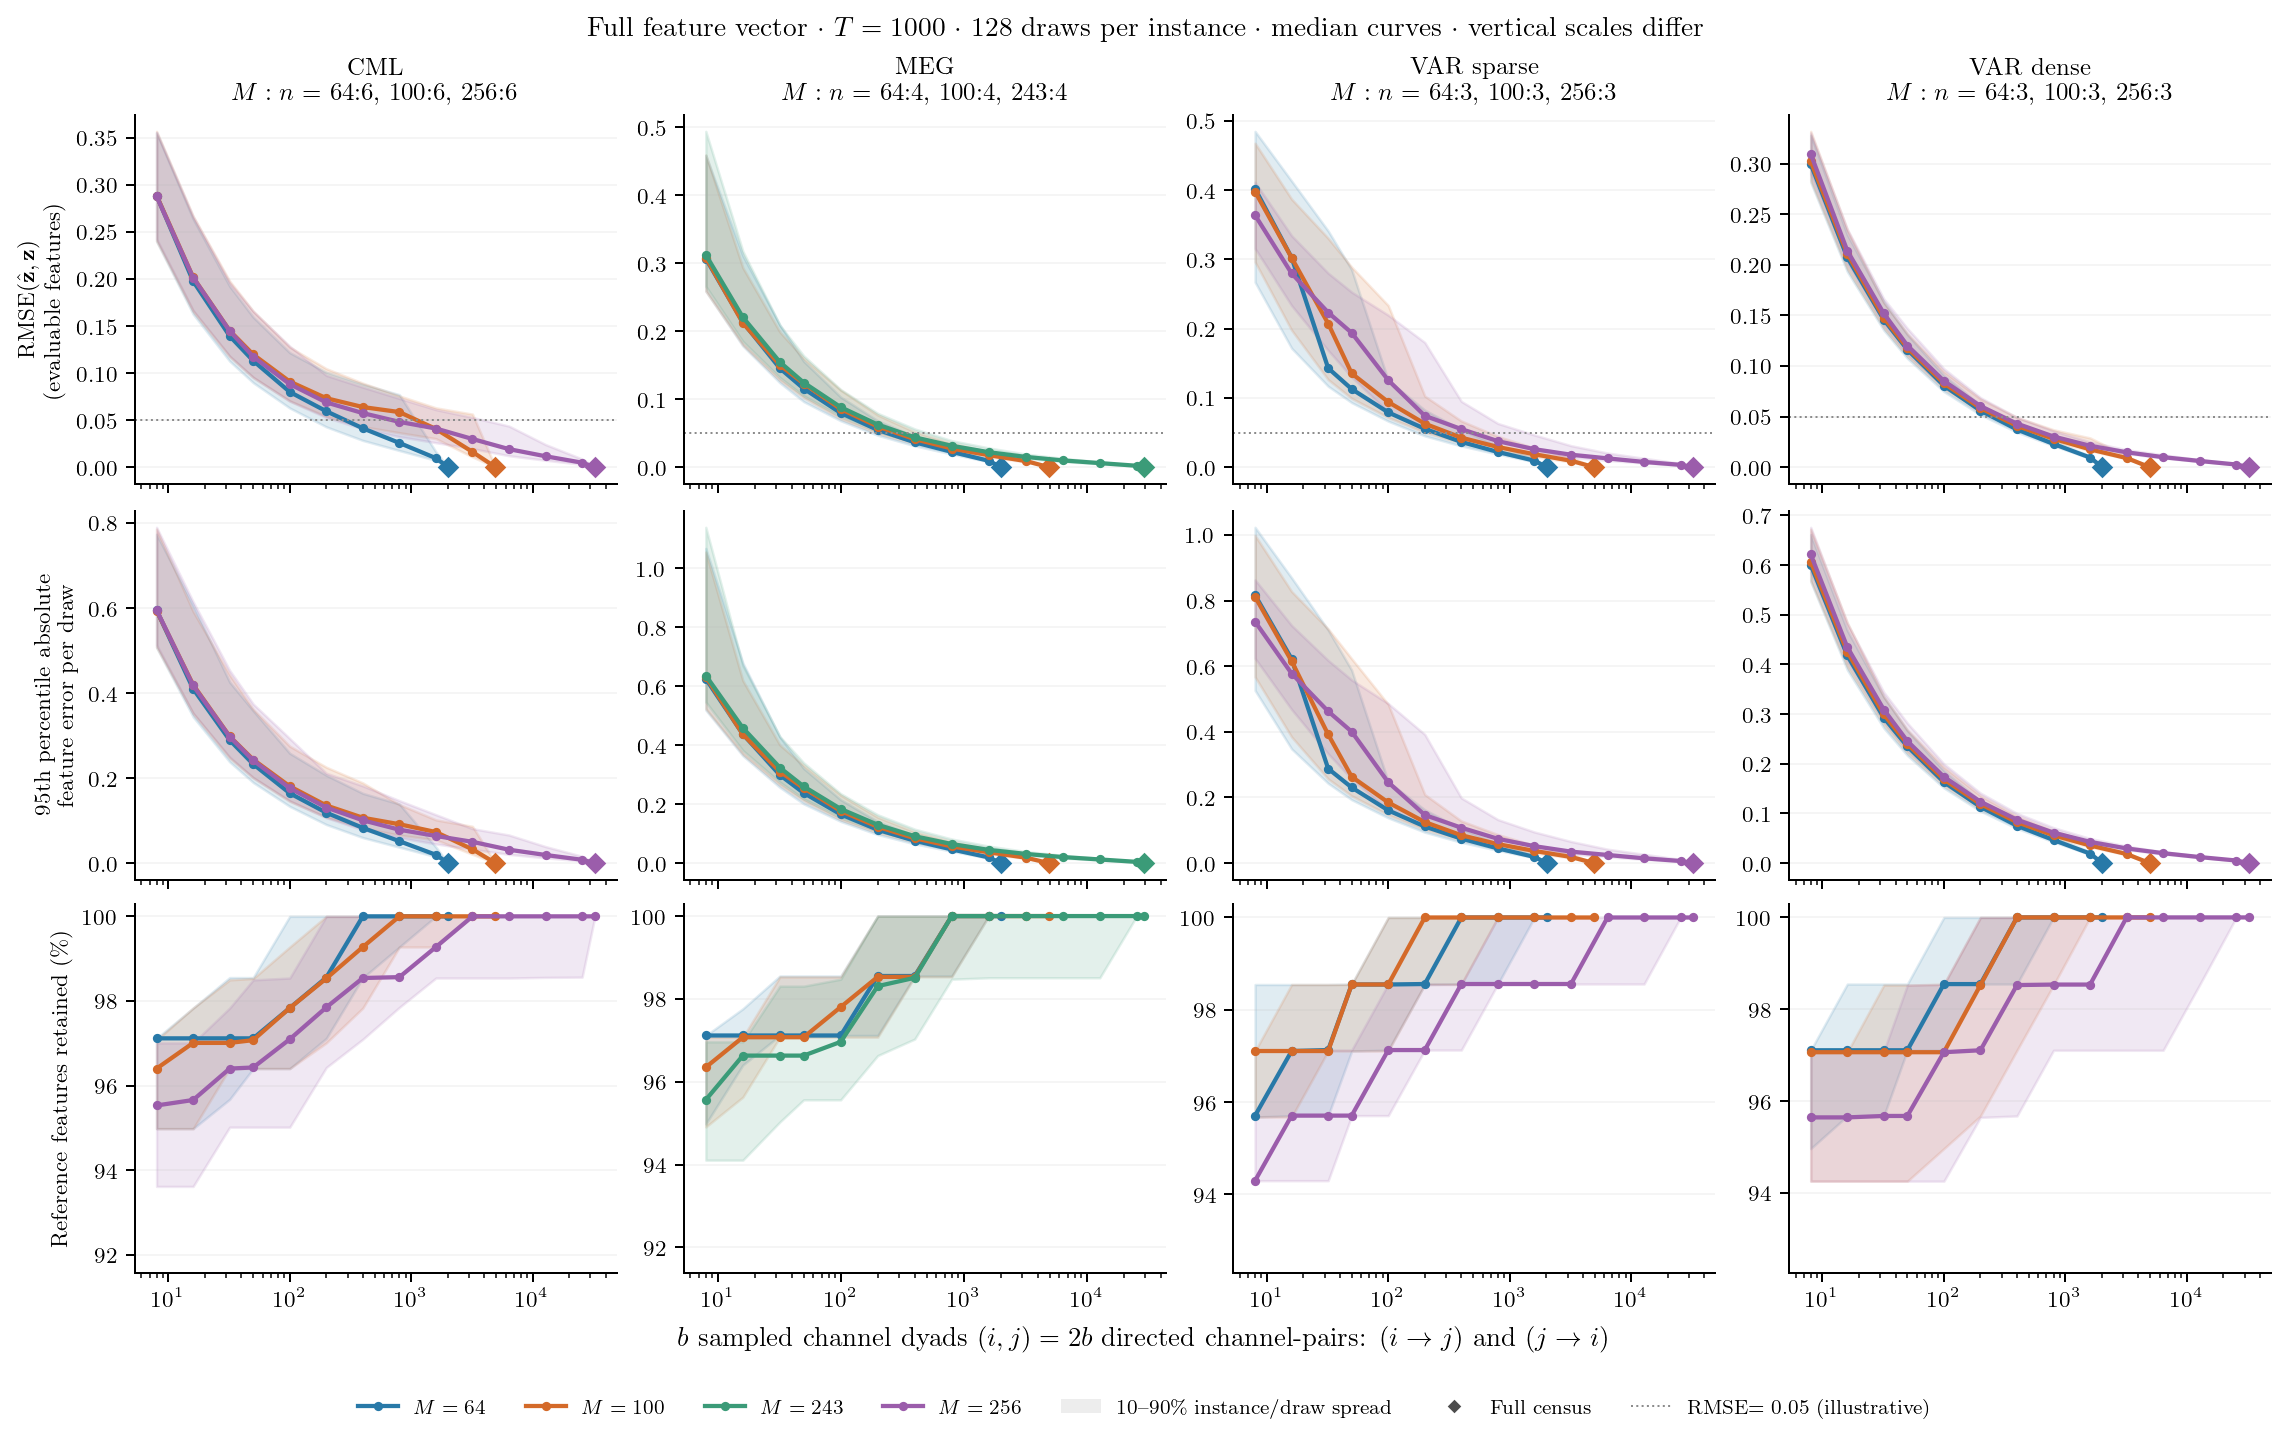

In [6]:
show_figure('full-vector-convergence.png')

Figures: `results/large_m_pair_baselines_260917/sampling-available/` (48-record update, 20 September 2026). [Methods and checks](../../docs/spi-pair-sampling-assessment.md).